# Perturbation Metrics

Evaluates three metrics across all perturbed datasets:

1. **Argmax accuracy** — fraction of positions where argmax(p) == true AA
2. **Mean JSD** — average Jensen-Shannon divergence between p and the one-hot ground truth
3. **BLOSUM-weighted score** — average dot product of p with softmax(BLOSUM62[true_aa, :]), rewarding mass on biochemically similar AAs

In [1]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

H5_PATH = Path.cwd().parent / 'data' / 'synthetic' / 'perturbed_n1000_seed42.h5'

with h5py.File(H5_PATH, 'r') as f:
    classes = list(f.attrs['classes'])

N_AA      = len(classes)
aa_to_idx = {a: i for i, a in enumerate(classes)}

DATASET_KEYS = [
    'ground_truth',
    'perturb_gamma50', 'perturb_gamma10', 'perturb_gamma3', 'perturb_gamma1',
    'scramble_1pct', 'scramble_5pct', 'scramble_10pct', 'scramble_20pct',
    'lowconf_1pct', 'lowconf_5pct', 'lowconf_10pct', 'lowconf_20pct',
]
LABELS = [
    'ground truth',
    'γ=50', 'γ=10', 'γ=3', 'γ=1',
    's=1%', 's=5%', 's=10%', 's=20%',
    'lc=1%', 'lc=5%', 'lc=10%', 'lc=20%',
]

with h5py.File(H5_PATH, 'r') as f:
    protein_ids = list(f.keys())
    sequences   = {pid: f[pid]['sequence'][()].decode() for pid in protein_ids}

print(f'Proteins: {len(protein_ids):,}')
print(f'Datasets: {DATASET_KEYS}')

Proteins: 1,000
Datasets: ['ground_truth', 'perturb_gamma50', 'perturb_gamma10', 'perturb_gamma3', 'perturb_gamma1', 'scramble_1pct', 'scramble_5pct', 'scramble_10pct', 'scramble_20pct', 'lowconf_1pct', 'lowconf_5pct', 'lowconf_10pct', 'lowconf_20pct']


In [2]:
# BLOSUM62 in standard NCBI order
_NCBI_ORDER = list('ARNDCQEGHILKMFPSTWVY')
_BLOSUM62_NCBI = np.array([
#   A   R   N   D   C   Q   E   G   H   I   L   K   M   F   P   S   T   W   Y   V
[   4, -1, -2, -2,  0, -1, -1,  0, -2, -1, -1, -1, -1, -2, -1,  1,  0, -3, -2,  0],
[  -1,  5,  0, -2, -3,  1,  0, -2,  0, -3, -2,  2, -1, -3, -2, -1, -1, -3, -2, -3],
[  -2,  0,  6,  1, -3,  0,  0,  0,  1, -3, -3,  0, -2, -3, -2,  1,  0, -4, -2, -3],
[  -2, -2,  1,  6, -3,  0,  2, -1, -1, -3, -4, -1, -3, -3, -1,  0, -1, -4, -3, -3],
[   0, -3, -3, -3,  9, -3, -4, -3, -3, -1, -1, -3, -1, -2, -3, -1, -1, -2, -2, -1],
[  -1,  1,  0,  0, -3,  5,  2, -2,  0, -3, -2,  1,  0,  3, -1,  0, -1, -2, -1, -2],
[  -1,  0,  0,  2, -4,  2,  5, -2,  0, -3, -3,  1, -2, -3, -1,  0, -1, -3, -2, -2],
[   0, -2,  0, -1, -3, -2, -2,  6, -2, -4, -4, -2, -3, -3, -2,  0, -2, -2, -3, -3],
[  -2,  0,  1, -1, -3,  0,  0, -2,  8, -3, -3, -1, -2, -1, -2, -1, -2, -2,  2, -3],
[  -1, -3, -3, -3, -1, -3, -3, -4, -3,  4,  2, -3,  1,  0, -3, -2, -1, -3, -1,  3],
[  -1, -2, -3, -4, -1, -2, -3, -4, -3,  2,  4, -2,  2,  0, -3, -2, -1, -2, -1,  1],
[  -1,  2,  0, -1, -3,  1,  1, -2, -1, -3, -2,  5, -1, -3, -1,  0, -1, -3, -2, -2],
[  -1, -1, -2, -3, -1,  0, -2, -3, -2,  1,  2, -1,  5,  0, -2, -1, -1, -1, -1,  1],
[  -2, -3, -3, -3, -2, -3, -3, -3, -1,  0,  0, -3,  0,  6, -4, -2, -2,  1,  3, -1],
[  -1, -2, -2, -1, -3, -1, -1, -2, -2, -3, -3, -1, -2, -4,  7, -1, -1, -4, -3, -2],
[   1, -1,  1,  0, -1,  0,  0,  0, -1, -2, -2,  0, -1, -2, -1,  4,  1, -3, -2, -2],
[   0, -1,  0, -1, -1, -1, -1, -2, -2, -1, -1, -1, -1, -2, -1,  1,  5, -2, -2,  0],
[  -3, -3, -4, -4, -2, -2, -3, -2, -2, -3, -2, -3, -1,  1, -4, -3, -2, 11,  2, -3],
[  -2, -2, -2, -3, -2, -1, -2, -3,  2, -1, -1, -2, -1,  3, -3, -2, -2,  2,  7, -1],
[   0, -3, -3, -3, -1, -2, -2, -3, -3,  3,  1, -2,  1, -1, -2, -2,  0, -3, -1,  4],
], dtype=np.float64)

# Reindex to match our classes order
_idx = [_NCBI_ORDER.index(aa) for aa in classes]
blosum62 = _BLOSUM62_NCBI[np.ix_(_idx, _idx)]

# Softmax each row to get weight vectors
def _softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

blosum_weights = np.array([_softmax(blosum62[i]) for i in range(N_AA)])

print('BLOSUM62 loaded and reindexed')
print(f'Weight matrix shape: {blosum_weights.shape}')
print(f'Row sums (should all be 1): {blosum_weights.sum(axis=1).round(6)}')

BLOSUM62 loaded and reindexed
Weight matrix shape: (20, 20)
Row sums (should all be 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [3]:
def argmax_accuracy(p, true_idx):
    return (p.argmax(axis=1) == true_idx).mean()


def mean_jsd(p, true_idx):
    """Mean JSD (log base 2, range [0,1]) between each row and its one-hot ground truth."""
    L = p.shape[0]
    q = np.zeros_like(p)
    q[np.arange(L), true_idx] = 1.0
    m = (p + q) / 2

    p_safe = np.clip(p, 1e-12, None)
    m_safe = np.clip(m, 1e-12, None)

    kl_pm = (p * np.log2(p_safe / m_safe)).sum(axis=1)
    kl_qm = np.log2(1.0 / m[np.arange(L), true_idx])  # one-hot: only one term

    return ((kl_pm + kl_qm) / 2).mean()


def blosum_score(p, true_idx):
    """Mean dot product of p with softmax(BLOSUM62[true_aa, :])."""
    W = blosum_weights[true_idx]  # (L, 20)
    return (p * W).sum(axis=1).mean()

In [4]:
results = {key: {'argmax_acc': [], 'mean_jsd': [], 'blosum_score': []} for key in DATASET_KEYS}

with h5py.File(H5_PATH, 'r') as f:
    for pid in protein_ids:
        seq      = sequences[pid]
        true_idx = np.array([aa_to_idx[aa] for aa in seq])
        for key in DATASET_KEYS:
            p = f[pid][key][()].astype(np.float64)
            results[key]['argmax_acc'].append(argmax_accuracy(p, true_idx))
            results[key]['mean_jsd'].append(mean_jsd(p, true_idx))
            results[key]['blosum_score'].append(blosum_score(p, true_idx))

# Aggregate
summary = pd.DataFrame({
    'dataset':      LABELS,
    'argmax_acc':   [np.mean(results[k]['argmax_acc'])   for k in DATASET_KEYS],
    'mean_jsd':     [np.mean(results[k]['mean_jsd'])     for k in DATASET_KEYS],
    'blosum_score': [np.mean(results[k]['blosum_score']) for k in DATASET_KEYS],
})

summary_display = summary.copy()
summary_display['argmax_acc']   = summary_display['argmax_acc'].map('{:.3%}'.format)
summary_display['mean_jsd']     = summary_display['mean_jsd'].map('{:.4f}'.format)
summary_display['blosum_score'] = summary_display['blosum_score'].map('{:.4f}'.format)
summary_display.columns = ['Dataset', 'Argmax Accuracy', 'Mean JSD', 'BLOSUM Score']
print(summary_display.to_string(index=False))

     Dataset Argmax Accuracy Mean JSD BLOSUM Score
ground truth        100.000%   0.0000       0.8721
        γ=50        100.000%   0.0017       0.8694
        γ=10         99.999%   0.0081       0.8596
         γ=3         99.392%   0.0236       0.8377
         γ=1         95.729%   0.0523       0.8031
        s=1%         99.057%   0.0094       0.8640
        s=5%         95.254%   0.0475       0.8311
       s=10%         90.520%   0.0948       0.7900
       s=20%         81.006%   0.1899       0.7078
       lc=1%         99.108%   0.0098       0.8615
       lc=5%         95.531%   0.0426       0.8294
      lc=10%         91.068%   0.0836       0.7896
      lc=20%         82.091%   0.1655       0.7095


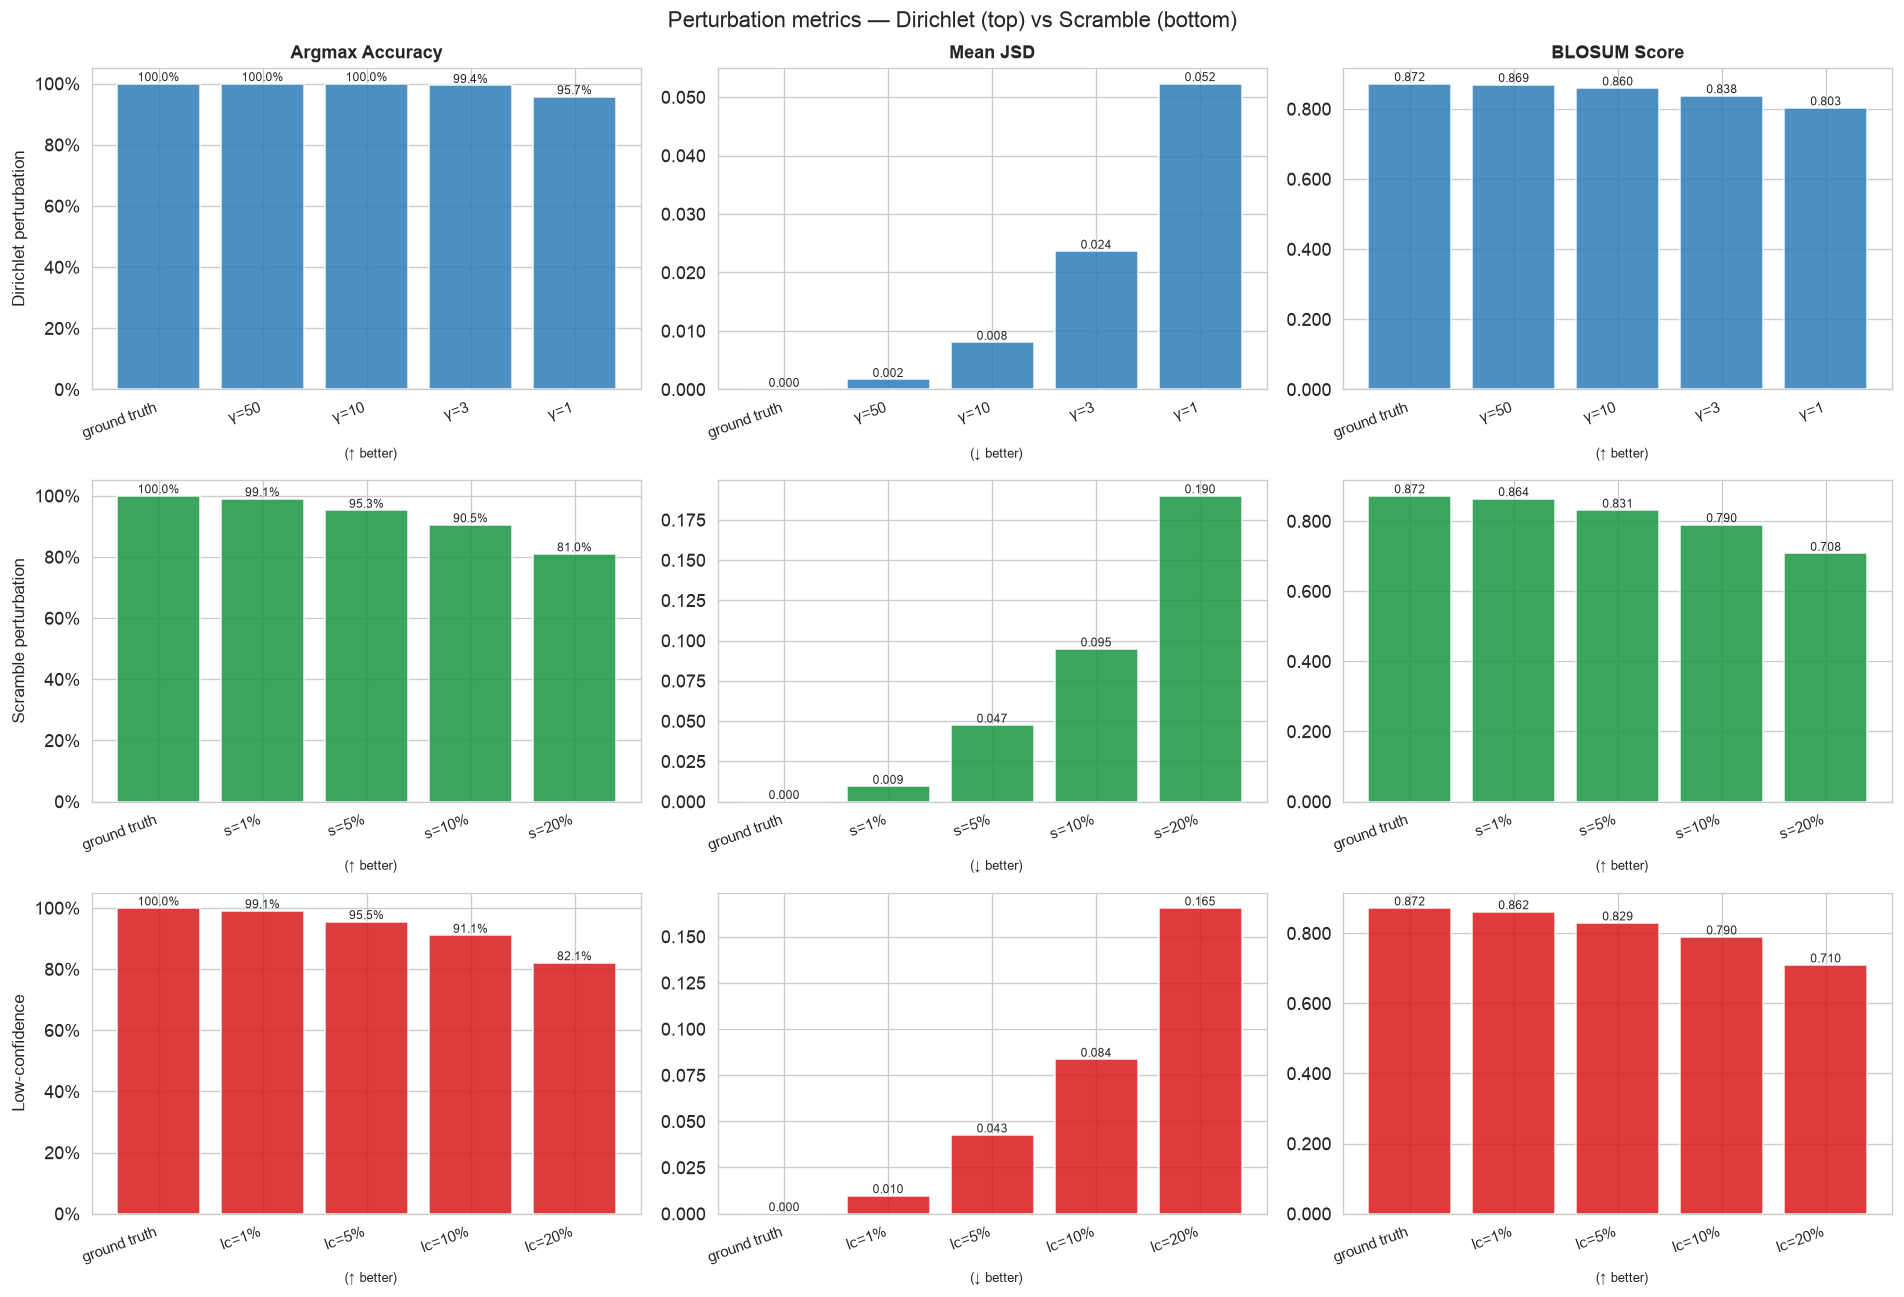

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))

metrics = [
    ('argmax_acc',   'Argmax Accuracy',  True,  mticker.PercentFormatter(xmax=1)),
    ('mean_jsd',     'Mean JSD',         False, mticker.FormatStrFormatter('%.3f')),
    ('blosum_score', 'BLOSUM Score',     True,  mticker.FormatStrFormatter('%.3f')),
]

groups = [
    ('Dirichlet perturbation', [0, 1, 2, 3, 4],   ['ground truth', 'γ=50', 'γ=10', 'γ=3', 'γ=1'],       '#2c7bb6'),
    ('Scramble perturbation',  [0, 5, 6, 7, 8],   ['ground truth', 's=1%', 's=5%', 's=10%', 's=20%'],   '#1a9641'),
    ('Low-confidence',         [0, 9, 10, 11, 12], ['ground truth', 'lc=1%', 'lc=5%', 'lc=10%', 'lc=20%'], '#d7191c'),
]

for row, (group_title, idx, xlabels, color) in enumerate(groups):
    for col, (metric, title, higher_better, formatter) in enumerate(metrics):
        ax = axes[row, col]
        vals = summary[metric].values[idx]
        bars = ax.bar(np.arange(len(idx)), vals, color=color, edgecolor='white', alpha=0.85)
        ax.set_xticks(np.arange(len(idx)))
        ax.set_xticklabels(xlabels, rotation=20, ha='right', fontsize=9)
        ax.yaxis.set_major_formatter(formatter)
        if row == 0:
            ax.set_title(title, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(group_title, fontsize=10)
        arrow = '  (↑ better)' if higher_better else '  (↓ better)'
        ax.set_xlabel(arrow, fontsize=8)
        for bar, val in zip(bars, vals):
            fmt = f'{val:.1%}' if metric == 'argmax_acc' else f'{val:.3f}'
            ax.text(bar.get_x() + bar.get_width()/2, val, fmt,
                    ha='center', va='bottom', fontsize=7)

fig.suptitle('Perturbation metrics — Dirichlet (top) vs Scramble (bottom)', fontsize=13)
fig.tight_layout()
plt.show()
